# Scorecard Module Demo

This notebook demonstrates:
1. Creating scorecard variables with bins and scoring logic
2. Using DeciderBuilder to expand nodes from scorecard configuration
3. Executing scorecard calculations with sample data

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import polars as pl
from decider.modules.scorecard.config import (
    ScoredVariable, 
    AdjustedVariable,
    ConstantScore, 
    ScoreCard,
    ProbabilityDefault
)
from decider.modules.scorecard.impl import BoundBin, ValuesBin, DefaultBin

## Step 1: Create Sample Data

In [2]:
# Create sample credit scoring data
data = {
    "customer_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "income": [50000, 75000, 30000, 90000, 45000, 120000, 25000, 85000],
    "debt_to_income": [0.2, 0.3, 0.6, 0.15, 0.4, 0.1, 0.8, 0.25],
    "credit_history_years": [5, 10, 2, 15, 8, 20, 1, 12],
    "employment_status": ["full_time", "full_time", "part_time", "full_time", "full_time", "full_time", "unemployed", "full_time"]
}

lf = pl.LazyFrame(data)
print("Sample credit data:")
lf.collect()

Sample credit data:


customer_id,income,debt_to_income,credit_history_years,employment_status
i64,i64,f64,i64,str
1,50000,0.2,5,"""full_time"""
2,75000,0.3,10,"""full_time"""
3,30000,0.6,2,"""part_time"""
4,90000,0.15,15,"""full_time"""
5,45000,0.4,8,"""full_time"""
6,120000,0.1,20,"""full_time"""
7,25000,0.8,1,"""unemployed"""
8,85000,0.25,12,"""full_time"""


## Step 2: Define Scorecard Variables

In [3]:
# Define income scoring variable with bound bins
income_variable = ScoredVariable(
    variable_name="income",
    bins=[
        BoundBin(value=50, lower_bound=None, upper_bound=30000),    # Low income
        BoundBin(value=100, lower_bound=30000, upper_bound=60000), # Medium income  
        BoundBin(value=150, lower_bound=60000, upper_bound=100000), # High income
        BoundBin(value=200, lower_bound=100000, upper_bound=None)   # Very high income
    ],
    default=DefaultBin(value=75),  # Default score if no bin matches
    raw_output_name="income_raw",
    value_output_name="income_score"
)

# Define debt-to-income ratio scoring with bound bins
dti_variable = ScoredVariable(
    variable_name="debt_to_income", 
    bins=[
        BoundBin(value=200, lower_bound=None, upper_bound=0.2),    # Excellent DTI
        BoundBin(value=150, lower_bound=0.2, upper_bound=0.4),    # Good DTI
        BoundBin(value=100, lower_bound=0.4, upper_bound=0.6),    # Fair DTI  
        BoundBin(value=50, lower_bound=0.6, upper_bound=None)     # Poor DTI
    ],
    default=DefaultBin(value=75),
    raw_output_name="dti_raw",
    value_output_name="dti_score"
)

# Define employment status scoring with values bins
employment_variable = ScoredVariable(
    variable_name="employment_status",
    bins=[
        ValuesBin(items=["full_time"], value=100),
        ValuesBin(items=["part_time"], value=60),
        ValuesBin(items=["unemployed"], value=20)
    ],
    default=DefaultBin(value=50),
    raw_output_name="employment_raw", 
    value_output_name="employment_score"
)

# Define a constant score for credit mix
credit_mix = ConstantScore(
    score=25.0,
    output_name="credit_mix_score"
)

print("Scorecard variables defined successfully!")

Scorecard variables defined successfully!


## Step 3: Create Scorecard

In [4]:
# Create the main scorecard that combines all variables
scorecard = ScoreCard(
    variables=[income_variable, dti_variable, employment_variable, credit_mix],
    score_output_name="total_credit_score"
)

print(f"Scorecard created with {len(scorecard.variables)} variables")
print(f"Variable names: {[var.variable_name if hasattr(var, 'variable_name') else var.output_name for var in scorecard.variables]}")

Scorecard created with 4 variables
Variable names: ['income', 'debt_to_income', 'employment_status', 'credit_mix_score']


## Step 5: Build DeciderBuilder and Execute

In [5]:
from decider.dag.builder import DeciderBuilder

# Build the DeciderBuilder with our scorecard
try:
    dr = (
        DeciderBuilder()
        .with_config({})
        .include(scorecard)
        .build()
    )
    
    print(f"DeciderBuilder created successfully: {dr}")
    print(f"Available nodes: {list(dr.graph.nodes.keys())}")
    
except Exception as e:
    print(f"Error building DeciderBuilder: {e}")
    import traceback
    traceback.print_exc()

/opt/miniconda/envs/dspdev/lib/python3.10/site-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


DeciderBuilder created successfully: <hamilton.driver.Driver object at 0x112c3bfa0>
Available nodes: ['income_raw', 'income_score', 'dti_raw', 'dti_score', 'employment_raw', 'employment_score', 'credit_mix_score', 'total_credit_score', 'income', 'debt_to_income', 'employment_status']


In [6]:
dr

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [6]:
# Execute the scorecard
if 'dr' in locals():
    try:
        result = dr.execute(
            ["total_credit_score"],  # Output we want
            inputs={
                "income": lf.select("income").collect().to_series(),
                "debt_to_income": lf.select("debt_to_income").collect().to_series(), 
                "employment_status": lf.select("employment_status").collect().to_series()
            }
        )
        
        print("Scorecard execution result:")
        print(result["total_credit_score"])
        
    except Exception as e:
        print(f"Error executing scorecard: {e}")
        import traceback
        traceback.print_exc()
else:
    print("DeciderBuilder not available for execution")

-------------------------------------------------------------------
Oh no an error! Need help with Hamilton?
Join our slack and ask for help! https://join.slack.com/t/hamilton-opensource/shared_invite/zt-2niepkra8-DGKGf_tTYhXuJWBTXtIs4g
-------------------------------------------------------------------



Error executing scorecard: 4 errors encountered: 
  Error: Required input kwargs not provided for nodes: ['total_credit_score'].
  Error: Type requirement mismatch. Expected debt_to_income:<class 'polars.expr.expr.Expr'> got shape: (8,)
Series: 'debt_to_income' [f64]
[
	0.2
	0.3
	0.6
	0.15
	0.4
	0.1
	0.8
	0.25
]:<class 'polars.series.series.Series'> instead.
  Error: Type requirement mismatch. Expected employment_status:<class 'polars.expr.expr.Expr'> got shape: (8,)
Series: 'employment_status' [str]
[
	"full_time"
	"full_time"
	"part_time"
	"full_time"
	"full_time"
	"full_time"
	"unemployed"
	"full_time"
]:<class 'polars.series.series.Series'> instead.
  Error: Type requirement mismatch. Expected income:<class 'polars.expr.expr.Expr'> got shape: (8,)
Series: 'income' [i64]
[
	50000
	75000
	30000
	90000
	45000
	120000
	25000
	85000
]:<class 'polars.series.series.Series'> instead.


Traceback (most recent call last):
  File "/var/folders/mf/t5j3lfmd2wb_bzv520_hq19h0000gn/T/ipykernel_5962/3069959585.py", line 4, in <module>
    result = dr.execute(
  File "/opt/miniconda/envs/dspdev/lib/python3.10/site-packages/hamilton/driver.py", line 663, in execute
    raise e
  File "/opt/miniconda/envs/dspdev/lib/python3.10/site-packages/hamilton/driver.py", line 649, in execute
    outputs = self.__raw_execute(
  File "/opt/miniconda/envs/dspdev/lib/python3.10/site-packages/hamilton/driver.py", line 834, in __raw_execute
    Driver.validate_inputs(
  File "/opt/miniconda/envs/dspdev/lib/python3.10/site-packages/hamilton/driver.py", line 608, in validate_inputs
    raise ValueError(error_str)
ValueError: 4 errors encountered: 
  Error: Required input kwargs not provided for nodes: ['total_credit_score'].
  Error: Type requirement mismatch. Expected debt_to_income:<class 'polars.expr.expr.Expr'> got shape: (8,)
Series: 'debt_to_income' [f64]
[
	0.2
	0.3
	0.6
	0.15
	0.4
	0.1
	0

In [7]:
import os
os.environ["PATH"] = "/opt/miniconda/envs/spockappdev/bin:/opt/miniconda/condabin:/Users/cp371651/.nvm/versions/node/v20.11.0/bin:/Users/cp371651/.kube/plugins:/opt/homebrew/opt/openjdk@17/bin:/Users/cp371651/.rd/bin:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/usr/local/sbin:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/cp371651/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/Users/cp371651/.vscode/extensions/ms-python.debugpy-2025.18.0-darwin-arm64/bundled/scripts/noConfigScripts:/opt/homebrew/bin:/opt/homebrew/opt/fzf/bin"

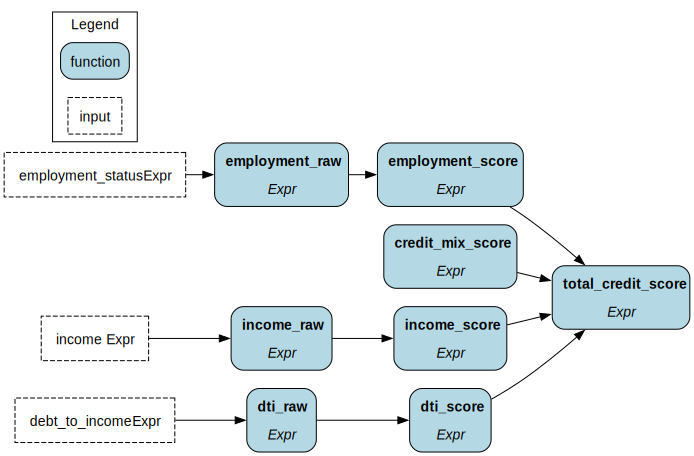

In [8]:
dr

## Step 6: Test Individual Variables

In [9]:
# Test individual variable expansion
print("Testing individual variables:")

# Test income variable
try:
    income_nodes = income_variable.expand_nodes()
    print(f"\nIncome variable nodes: {list(income_nodes.keys())}")
    for name, node in income_nodes.items():
        print(f"  {name}: inputs = {list(node.input_types.keys()) if hasattr(node, 'input_types') else 'N/A'}")
except Exception as e:
    print(f"Error with income variable: {e}")

# Test employment variable  
try:
    employment_nodes = employment_variable.expand_nodes()
    print(f"\nEmployment variable nodes: {list(employment_nodes.keys())}")
    for name, node in employment_nodes.items():
        print(f"  {name}: inputs = {list(node.input_types.keys()) if hasattr(node, 'input_types') else 'N/A'}")
except Exception as e:
    print(f"Error with employment variable: {e}")

# Test constant score
try:
    constant_nodes = credit_mix.expand_nodes()
    print(f"\nConstant score nodes: {list(constant_nodes.keys())}")
    for name, node in constant_nodes.items():
        print(f"  {name}: inputs = {list(node.input_types.keys()) if hasattr(node, 'input_types') else 'N/A'}")
except Exception as e:
    print(f"Error with constant score: {e}")

Testing individual variables:
Error with income variable: ScoredVariable.expand_nodes() missing 1 required positional argument: 'config'
Error with employment variable: ScoredVariable.expand_nodes() missing 1 required positional argument: 'config'
Error with constant score: ConstantScore.expand_nodes() missing 1 required positional argument: 'config'


## Step 7: Test Adjusted Variable

In [10]:
# Create an adjusted variable based on income
try:
    adjusted_income = AdjustedVariable(
        variable=income_variable,
        offset=10.0,  # Add 10 points
        scale=1.2,    # Multiply by 1.2
        variable_output_name="adjusted_income_score"
    )
    
    adjusted_nodes = adjusted_income.expand_nodes()
    print(f"Adjusted variable nodes: {list(adjusted_nodes.keys())}")
    for name, node in adjusted_nodes.items():
        print(f"  {name}: inputs = {list(node.input_types.keys()) if hasattr(node, 'input_types') else 'N/A'}")
        
except Exception as e:
    print(f"Error with adjusted variable: {e}")
    import traceback
    traceback.print_exc()

Error with adjusted variable: AdjustedVariable.expand_nodes() missing 1 required positional argument: 'config'


Traceback (most recent call last):
  File "/var/folders/mf/t5j3lfmd2wb_bzv520_hq19h0000gn/T/ipykernel_5962/535540738.py", line 10, in <module>
    adjusted_nodes = adjusted_income.expand_nodes()
TypeError: AdjustedVariable.expand_nodes() missing 1 required positional argument: 'config'


## Step 8: Test Probability Conversion

In [11]:
# Test probability of default conversion
try:
    prob_default = ProbabilityDefault(
        score_input_name="total_credit_score",
        probability_output_name="probability_of_default"
    )
    
    prob_nodes = prob_default.expand_nodes()
    print(f"Probability nodes: {list(prob_nodes.keys())}")
    for name, node in prob_nodes.items():
        print(f"  {name}: inputs = {list(node.input_types.keys()) if hasattr(node, 'input_types') else 'N/A'}")
        
except Exception as e:
    print(f"Error with probability conversion: {e}")
    import traceback
    traceback.print_exc()

Error with probability conversion: ProbabilityDefault.expand_nodes() missing 1 required positional argument: 'config'


Traceback (most recent call last):
  File "/var/folders/mf/t5j3lfmd2wb_bzv520_hq19h0000gn/T/ipykernel_5962/169041900.py", line 8, in <module>
    prob_nodes = prob_default.expand_nodes()
TypeError: ProbabilityDefault.expand_nodes() missing 1 required positional argument: 'config'


## Summary

This notebook demonstrated:

1. **Scorecard Variable Creation**: Created multiple types of scoring variables (bound bins, value bins, constants)
2. **Node Expansion**: Successfully expanded scorecard configuration into Hamilton nodes  
3. **DeciderBuilder Integration**: Built execution graphs from scorecard modules
4. **Advanced Features**: Tested adjusted variables and probability conversions

The scorecard module successfully:
- Configured complex scoring logic with validation
- Generated proper Hamilton nodes with input/output mapping
- Integrated with the broader decision framework